In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import torch
import torch_geometric
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, EdgeConv, DynamicEdgeConv
from torcheval.metrics import MulticlassAUROC, MulticlassAccuracy
from tqdm import tqdm


sys.path.append("../")

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_with_track_id_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_with_track_id_pixel_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_with_track_id_pixel_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)


# Only use pixel data
X = np.concatenate([bg_pixel_spacetime, sig_pixel_spacetime], axis=0)
y = np.concatenate([np.zeros(len(bg_pixel_spacetime)),np.ones(len(sig_pixel_spacetime))], axis=0)

X = X[:, :, :-1] # Remove track_id for input features
track_id = X[:, :, -1]  # Extract track_id for potential use

shuffled_indices = np.random.permutation(len(X))
X = X[shuffled_indices]
y = y[shuffled_indices]
track_id = track_id[shuffled_indices]

In [4]:
import torch
from torch_geometric.data import Data, Batch
from itertools import combinations

def batch_events_to_variable_graphs(events : torch.Tensor) -> Batch:
    """
    Convert a batch of events (padded) to a single PyG Batch object with variable number of graphs per event.
    Time is assumed to be at the last column (-1).
    
    Args:
        events (torch.Tensor): [num_events, num_hits, feature_dim] padded with -1
                               last column must be time

    Returns:
        Batch: PyG Batch object containing all graphs from all events
    """
    all_graphs = []
    event_indices = []

    for event_idx, event in enumerate(events):
        valid_hits = event[event[:, -1] != -1]

        times = valid_hits[:, -1]
        positions = valid_hits[:, :-2]
        layers = valid_hits[:, -2]  # Assuming layer is the second last feature

        unique_times = np.unique(times)
        for t in unique_times:
            mask = times == t
            masked_positions = positions[mask]
            masked_layers = layers[mask]
            num_nodes = masked_positions.size(0)
            if num_nodes == 0:
                continue

            edges = []
            for u, v in combinations(range(num_nodes), 2):
                if masked_layers[u] == masked_layers[v]:
                    continue
                if torch.abs(masked_layers[u] - masked_layers[v]) > 1:
                    continue
                edges.append([u, v])
                edges.append([v, u])
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
            nodes = masked_positions
            all_graphs.append(Data(x=nodes, edge_index=edge_index))
            event_indices.append(event_idx)

    # Batch all graphs together
    batch = Batch.from_data_list(all_graphs)
    batch.event_batch = torch.tensor(event_indices, dtype=torch.long)
    return batch


In [5]:
from torch.utils.data import Dataset, DataLoader


class EventDataset(Dataset):
    def __init__(self, X, y, shuffle=True, num_classes=2):
        if shuffle:
            indices = np.arange(len(X))
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]
        self.X = X
        self.y = y
        self.num_classes = num_classes


    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float), torch.nn.functional.one_hot(torch.tensor(self.y[idx], dtype=torch.long), num_classes=self.num_classes).float()
    
class GraphSetDataLoader:
    def __init__(self, dataset, batch_size=32, shuffle=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):
        indices = np.arange(len(self.dataset))
        if self.shuffle:
            np.random.shuffle(indices)

        for start_idx in range(0, len(self.dataset), self.batch_size):
            batch_indices = indices[start_idx:min(start_idx + self.batch_size, len(self.dataset))]
            batch_events = [self.dataset[i][0] for i in batch_indices]
            batch_labels = torch.stack([self.dataset[i][1] for i in batch_indices])
            padded_events = torch.nn.utils.rnn.pad_sequence(batch_events, batch_first=True, padding_value=-1)
            batch_graphs = batch_events_to_variable_graphs(padded_events)
            yield batch_graphs, batch_labels

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size  # Ceiling division

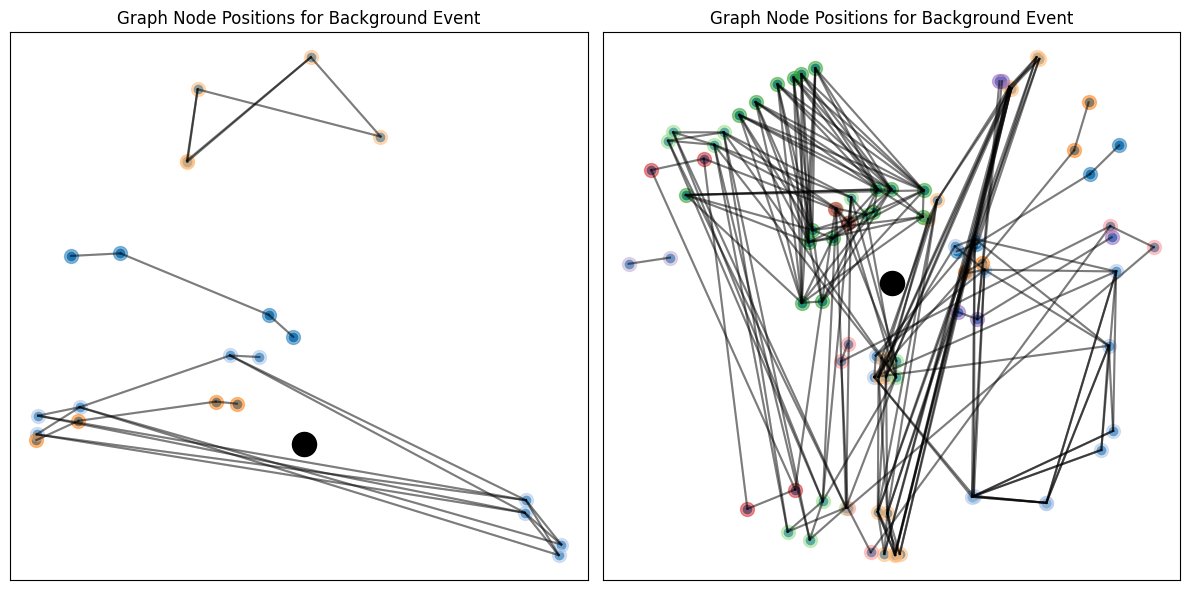

In [25]:
event_index = 0

def plot_graph(X,y, track_id, ax):
    graph = batch_events_to_variable_graphs(torch.tensor(np.expand_dims(X, axis = 0), dtype=torch.float))
    nodes = graph.x
    edges = graph.edge_index
    ax.scatter(nodes[:, 0].cpu(), nodes[:, 1].cpu())
    for edge in edges.t().cpu().numpy():
        ax.plot([nodes[edge[0], 0].cpu(), nodes[edge[1], 0].cpu()],
            [nodes[edge[0], 1].cpu(), nodes[edge[1], 1].cpu()], 'k-', alpha=0.3)
    track_mask = track_id > 0
    color_id = 0
    color_map = plt.colormaps['tab20']  # Get a colormap with 20 distinct colors
    for tracks in np.unique(track_id[track_mask]):
        if tracks == -1:
            continue
        if tracks == 0:
            continue
        ax.scatter(X[tracks == track_id, 0], X[tracks == track_id, 1], s=100, alpha=0.5, color=color_map(color_id))
        color_id += 1

    ax.set_title("Graph Node Positions")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    event_type = "Signal" if y== 1 else "Background"
    ax.set_title(f"Graph Node Positions for {event_type} Event")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.scatter([0], [0], alpha=1, color='black', s = 300, marker='o')

fig, ax  = plt.subplots(1, 2, figsize=(12, 6))
plot_graph(X[event_index], y[event_index], track_id[event_index], ax[0])
plot_graph(X[event_index + 1], y[event_index + 1], track_id[event_index + 1], ax[1])
fig.tight_layout()

In [7]:
import torch
from torch import nn

class SequenceGNNClassifier(nn.Module):
    def __init__(self, gnn: nn.Module, classifier_module: nn.Module):
        """
        gnn: graph-level embedding module
        classifier_module: sequence classifier that takes [num_graphs_in_event, embed_dim] per event
        """
        super().__init__()
        self.gnn = gnn
        self.classifier_module = classifier_module

    def forward(self, batch):
        """
        batch: PyG Batch object with attributes:
            - x: [num_nodes_total, feature_dim]
            - edge_index: [2, num_edges_total]
            - batch: [num_nodes_total] mapping nodes to graphs
            - event_batch: [num_graphs_total] mapping graphs to events
        Returns:
            - classifier_outputs: [num_events, num_classes]
        """
        x, edge_index, graph_batch, event_batch = batch.x, batch.edge_index, batch.batch, batch.event_batch
        graph_embeddings = self.gnn(x, edge_index, graph_batch)  # [num_graphs_total, embed_dim]

        if not hasattr(batch, 'event_batch'):
            raise ValueError("Batch must have 'event_batch' attribute")

        classifier_outputs = self.classifier_module(graph_embeddings, event_batch)  # [num_events, num_classes]
        return classifier_outputs # [num_events, num_classes]


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, global_mean_pool, global_max_pool
from torch_geometric.utils import add_self_loops, softmax


class EdgeWeightGenerator(nn.Module):
    """First layer: learns initial edge weights from node pairs."""
    def __init__(self, in_dim, hidden_dim=64):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index):
        src, dst = edge_index
        edge_feat = torch.cat([x[src], x[dst]], dim=-1)
        edge_weight = self.edge_mlp(edge_feat).squeeze(-1)  # [num_edges]

        # Normalize per source node (softmax like GAT)
        edge_weight = softmax(edge_weight, src)

        return edge_weight


class WeightedMessagePassing(MessagePassing):
    """Message passing layer that uses learned edge weights."""
    def __init__(self, in_dim, out_dim):
        super().__init__(aggr="add")
        self.node_mlp = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim)
        )

    def forward(self, x, edge_index, edge_weight):
        return self.propagate(edge_index, x=x, edge_weight=edge_weight)

    def message(self, x_j, edge_weight):
        return edge_weight.view(-1, 1) * self.node_mlp(x_j)


class EdgeWeightUpdater(nn.Module):
    """Recomputes new edge weights after some message passing."""
    def __init__(self, node_dim, hidden_dim=64):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index):
        src, dst = edge_index
        edge_feat = torch.cat([x[src], x[dst]], dim=-1)
        new_weight = self.edge_mlp(edge_feat).squeeze(-1)

        # Normalize per source node
        new_weight = softmax(new_weight, src)

        return new_weight


class GraphEmbedder(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, emb_dim=128, add_self_loops_flag=True):
        super().__init__()
        self.edge_init = EdgeWeightGenerator(in_dim, hidden_dim)
        self.conv1 = WeightedMessagePassing(in_dim, hidden_dim)

        self.edge_updater = EdgeWeightUpdater(hidden_dim, hidden_dim)
        self.conv2 = WeightedMessagePassing(hidden_dim, hidden_dim)

        self.fc = nn.Linear(2 * hidden_dim, emb_dim)
        self.add_self_loops_flag = add_self_loops_flag

    def forward(self, x, edge_index, batch):
        num_nodes = x.size(0)

        # Optionally add self-loops
        if self.add_self_loops_flag:
            edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)

        # 1. Generate initial edge weights
        edge_weight = self.edge_init(x, edge_index)

        # 2. First message passing
        x = F.relu(self.conv1(x, edge_index, edge_weight))

        # 3. Update edge weights
        edge_weight = self.edge_updater(x, edge_index)

        # 4. Second message passing with updated weights
        x = F.relu(self.conv2(x, edge_index, edge_weight))

        # 5. Pooling → fixed size embedding
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)

        return self.fc(x)


In [9]:
from torch_src.model.components import get_mlp, TransformerBlock, PoolerTransformerBlock

class SequenceClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_classes=2):
        super().__init__()
        self.embedding_dim = hidden_dim
        self.embedding_layer = get_mlp(input_dim, hidden_dim, num_layers=3)
        self.transformer = TransformerBlock(hidden_dim, num_heads=4)
        self.pooler = PoolerTransformerBlock(hidden_dim, num_heads=4)
        self.classifier = get_mlp(hidden_dim, num_classes, num_layers=3)

    def forward(self, graph_embeddings, event_batch):
        """
        graph_embeddings: [num_graphs_total, input_dim]
        event_batch: [num_graphs_total] mapping graphs to events
        Returns:
            - logits: [num_events, num_classes]
        """
        x = self.embedding_layer(graph_embeddings)
        x = self.transformer(x, event_batch)
        x = self.pooler(x, event_batch)
        logits = self.classifier(x)
        return nn.functional.softmax(logits, dim=-1)

In [10]:
graph_set_classifier = SequenceGNNClassifier(
    gnn=GraphEmbedder(in_dim=3, hidden_dim=10, emb_dim=16),
    classifier_module=SequenceClassifier(input_dim=16, hidden_dim=16, num_classes=2)
)

In [11]:
# Example forward pass
print(f"Model has {sum(p.numel() for p in graph_set_classifier.parameters() if p.requires_grad)} trainable parameters")

Model has 6374 trainable parameters


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
train_dataset = EventDataset(X_train, y_train, shuffle=True, num_classes=2)
val_dataset = EventDataset(X_val, y_val, shuffle=False, num_classes=2)
train_loader = GraphSetDataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = GraphSetDataLoader(val_dataset, batch_size=512, shuffle=False)


In [13]:
for test_batch in train_loader:
    batch_graph_set, batch_labels = test_batch
    batch_graph_set = batch_graph_set.to(device)
    batch_labels = batch_labels.to(device)
    print(f"On device: {batch_graph_set.x.device}, {batch_labels.device}")
    break


On device: cpu, cpu


In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(graph_set_classifier.parameters(), lr=1e-4)
auc_metric = MulticlassAUROC(num_classes=2)
acc_metric = MulticlassAccuracy(num_classes=2)

In [15]:
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
for epoch in range(10):
    graph_set_classifier.train()
    total_loss = 0
    for batch_graphs, batch_labels in tqdm(train_loader):
        optimizer.zero_grad()
        outputs = graph_set_classifier(batch_graphs)
        loss = loss_fn(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_labels.size(0)
    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")
    history["train_loss"].append(avg_loss)
    graph_set_classifier.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []
    auc_metric.reset()
    acc_metric.reset()
    with torch.no_grad():
        for batch_graphs, batch_labels in val_loader:
            outputs = graph_set_classifier(batch_graphs)
            loss = loss_fn(outputs, batch_labels)
            total_val_loss += loss.item() * batch_labels.size(0)
            all_preds.append(outputs)
            all_labels.append(batch_labels)
            auc_metric.update(outputs, batch_labels)
            acc_metric.update(outputs, batch_labels)
    avg_val_loss = total_val_loss / len(val_dataset)
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    val_auc = auc_metric.compute().item()
    val_acc = acc_metric.compute().item()
    print(f"Epoch {epoch+1}, Val Loss: {avg_val_loss:.4f}, Val AUC: {val_auc:.4f}, Val Acc: {val_acc:.4f}")
    history["val_loss"].append(avg_val_loss)
    history["val_auc"].append(val_auc)
    history["val_acc"].append(val_acc)
    # Save model checkpoint
    torch.save(graph_set_classifier.state_dict(), f"{MODEL_DIR}/graph_set_classifier_epoch{epoch+1}.pth")


  0%|          | 0/573 [00:01<?, ?it/s]


RuntimeError: expected scalar type Long but found Float